In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [6]:
%pip install -q nibabel opencv-python-headless pillow tqdm matplotlib

In [7]:
from __future__ import annotations

import json
import time
from pathlib import Path
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

In [8]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project"
)

DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
METADATA_ROOT = DATA_ROOT / "metadata"

EXTRACTED_ROOT = PROCESSED_ROOT / "extracted"
GENERATION_ROOT = PROCESSED_ROOT / "generation"

ORIGINAL_REPO = PROJECT_ROOT / "github" / "original"
OUR_REPO = PROJECT_ROOT / "github" / "our"

ORIGINAL_SCRIPT = (
    ORIGINAL_REPO
    / "dataset"
    / "code"
    / "01_extract_png_images_from_nii.py"
)

for directory in [
    EXTRACTED_ROOT,
    GENERATION_ROOT,
    METADATA_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "RAW_ROOT": RAW_ROOT,
    "EXTRACTED_ROOT": EXTRACTED_ROOT,
    "GENERATION_ROOT": GENERATION_ROOT,
    "METADATA_ROOT": METADATA_ROOT,
    "ORIGINAL_SCRIPT": ORIGINAL_SCRIPT,
}

for name, path in paths.items():
    print(f"{name:18s}: {path}")
    print(f"{'':18s}  exists = {path.exists()}")

PROJECT_ROOT      : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project
                    exists = True
RAW_ROOT          : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw
                    exists = True
EXTRACTED_ROOT    : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/extracted
                    exists = True
GENERATION_ROOT   : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/generation
                    exists = True
METADATA_ROOT     : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/metadata
                    exists = True
ORIGINAL_SCRIPT   : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/github/original/dataset/code/01_extract_png_images_from_nii.py
                    exists = True


In [9]:
assert ORIGINAL_SCRIPT.is_file(), (
    f"Original preprocessing script was not found:\n{ORIGINAL_SCRIPT}"
)

print("Original script found:")
print(ORIGINAL_SCRIPT)

print("\nFirst 1,500 characters of the original file:\n")
print(ORIGINAL_SCRIPT.read_text(encoding="utf-8")[:1500])

Original script found:
/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/github/original/dataset/code/01_extract_png_images_from_nii.py

First 1,500 characters of the original file:

"""
Script for extracting PNG images from raw NII data. Scripts saves raw images in extracted directory. Images saved
under generation directory have modified segmentation masks with information about brain region.
"""
from glob import glob
from json import dumps
from os.path import isfile
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
from PIL.Image import fromarray
from nibabel import load
from tqdm import tqdm


MAX_VALUE_OF_CLASS = 4


def get_image(path: str, source_image: Optional[np.ndarray] = None) -> tuple[np.ndarray, list]:
    empty_seg_number = None
    img = load(path).get_fdata()[40:200, 11:235, 20:140:20]

    if source_image is not None:
        empty_seg_number = [np.isclose(img[..., i].max(), 0) for i in range(img.shape[2])]

        _, thresh = c

In [10]:
patient_dirs = sorted(
    path
    for path in RAW_ROOT.glob("BraTS2021_*")
    if path.is_dir()
)

print("Raw root:", RAW_ROOT)
print("Patients found:", len(patient_dirs))

assert len(patient_dirs) == 1251, (
    f"Expected 1,251 patient folders, found {len(patient_dirs)}."
)

print("\nFirst ten patients:")
for patient_dir in patient_dirs[:10]:
    print(" ", patient_dir.name)

Raw root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw
Patients found: 1251

First ten patients:
  BraTS2021_00000
  BraTS2021_00002
  BraTS2021_00003
  BraTS2021_00005
  BraTS2021_00006
  BraTS2021_00008
  BraTS2021_00009
  BraTS2021_00011
  BraTS2021_00012
  BraTS2021_00014


In [11]:
missing_flair = []
missing_seg = []

for patient_dir in tqdm(patient_dirs, desc="Checking raw files"):
    patient_name = patient_dir.name

    flair_path = patient_dir / f"{patient_name}_flair.nii.gz"
    seg_path = patient_dir / f"{patient_name}_seg.nii.gz"

    if not flair_path.is_file():
        missing_flair.append(str(flair_path))

    if not seg_path.is_file():
        missing_seg.append(str(seg_path))

print("Missing FLAIR files:", len(missing_flair))
print("Missing segmentation files:", len(missing_seg))

assert not missing_flair, missing_flair[:5]
assert not missing_seg, missing_seg[:5]

print("All 1,251 patients have the required FLAIR and segmentation files.")

Checking raw files:   0%|          | 0/1251 [00:00<?, ?it/s]

Missing FLAIR files: 0
Missing segmentation files: 0
All 1,251 patients have the required FLAIR and segmentation files.


In [17]:
MAX_VALUE_OF_CLASS = 4
EXPECTED_VOLUME_SHAPE = (240, 240, 155)
EXPECTED_SELECTED_SHAPE = (160, 224, 6)
SELECTED_SLICE_INDICES = [20, 40, 60, 80, 100, 120]


def get_image(
    path: str | Path,
    source_image: Optional[np.ndarray] = None,
) -> tuple[np.ndarray, Optional[list[bool]]]:
    """Reproduce the original repository's preprocessing logic."""

    path = Path(path)

    if not path.is_file():
        raise FileNotFoundError(f"Input file does not exist: {path}")

    nii = nib.load(str(path))
    full_volume = nii.get_fdata()

    if full_volume.shape != EXPECTED_VOLUME_SHAPE:
        raise ValueError(
            f"Unexpected shape for {path.name}: {full_volume.shape}. "
            f"Expected {EXPECTED_VOLUME_SHAPE}."
        )

    img = full_volume[
        40:200,
        11:235,
        20:140:20,
    ]

    if img.shape != EXPECTED_SELECTED_SHAPE:
        raise ValueError(
            f"Unexpected selected shape for {path.name}: {img.shape}. "
            f"Expected {EXPECTED_SELECTED_SHAPE}."
        )

    empty_seg_number = None

    if source_image is not None:
        # This check is performed before adding the whole-brain class.
        empty_seg_number = [
            bool(np.isclose(img[..., i].max(), 0))
            for i in range(img.shape[2])
        ]

        # Reproduce the original thresholding and morphology operations.
        _, thresh = cv2.threshold(
            source_image,
            1,
            255,
            cv2.THRESH_BINARY,
        )

        thresh = cv2.erode(
            thresh,
            np.ones((3, 3), np.uint8),
            iterations=1,
        )

        thresh = cv2.morphologyEx(
            thresh,
            cv2.MORPH_CLOSE,
            np.ones((6, 6), np.uint8),
        )

        thresh = np.where(
            thresh == 255,
            3,
            0,
        )

        # Preserve lesion labels; add class 3 only where the lesion mask is 0.
        img = np.where(
            img == 0,
            thresh,
            img,
        )

    img = img.astype("float32")

    if not np.isclose(img.max(), 0):
        if source_image is not None:
            img = img / MAX_VALUE_OF_CLASS
        else:
            img = (
                (img - img.min())
                / (img.max() - img.min())
            )

    return (
        (img * 255).astype("uint8"),
        empty_seg_number,
    )

In [18]:
sample_patient_dir = patient_dirs[0]
sample_patient_name = sample_patient_dir.name

sample_flair_path = (
    sample_patient_dir
    / f"{sample_patient_name}_flair.nii.gz"
)

sample_seg_path = (
    sample_patient_dir
    / f"{sample_patient_name}_seg.nii.gz"
)

sample_flair, _ = get_image(sample_flair_path)
sample_seg_original, _ = get_image(sample_seg_path)
sample_seg_condition, sample_healthy_flags = get_image(
    sample_seg_path,
    source_image=sample_flair,
)

print("Patient:", sample_patient_name)
print("FLAIR shape:", sample_flair.shape)
print("Original mask shape:", sample_seg_original.shape)
print("Conditioning mask shape:", sample_seg_condition.shape)

print("FLAIR dtype:", sample_flair.dtype)
print("Original mask values:", np.unique(sample_seg_original))
print("Conditioning mask values:", np.unique(sample_seg_condition))

print("\nSelected slices:")
for local_index, original_index in enumerate(SELECTED_SLICE_INDICES):
    status = (
        "healthy"
        if sample_healthy_flags[local_index]
        else "unhealthy"
    )
    print(
        f"  local {local_index:02d} -> original slice "
        f"{original_index:3d}: {status}"
    )

assert sample_flair.shape == EXPECTED_SELECTED_SHAPE
assert sample_seg_original.shape == EXPECTED_SELECTED_SHAPE
assert sample_seg_condition.shape == EXPECTED_SELECTED_SHAPE
assert sample_flair.dtype == np.uint8
assert sample_seg_original.dtype == np.uint8
assert sample_seg_condition.dtype == np.uint8

print("\nOne-patient preprocessing check passed.")

Patient: BraTS2021_00000
FLAIR shape: (160, 224, 6)
Original mask shape: (160, 224, 6)
Conditioning mask shape: (160, 224, 6)
FLAIR dtype: uint8
Original mask values: [  0  63 127 255]
Conditioning mask values: [  0  63 127 191 255]

Selected slices:
  local 00 -> original slice  20: healthy
  local 01 -> original slice  40: healthy
  local 02 -> original slice  60: unhealthy
  local 03 -> original slice  80: unhealthy
  local 04 -> original slice 100: healthy
  local 05 -> original slice 120: healthy

One-patient preprocessing check passed.


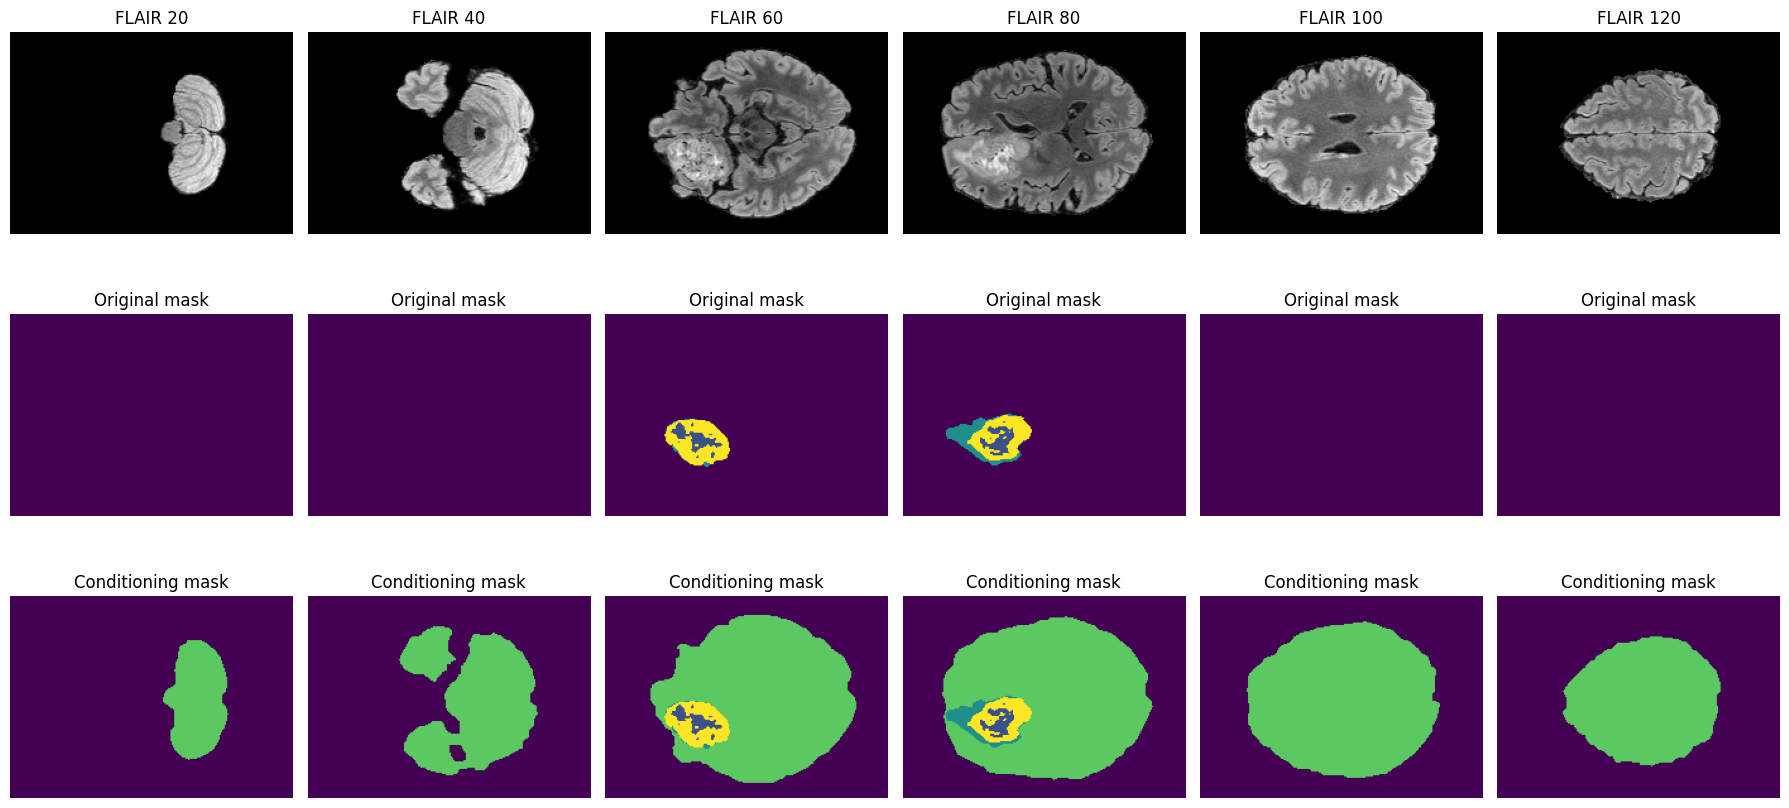

In [19]:
fig, axes = plt.subplots(
    3,
    len(SELECTED_SLICE_INDICES),
    figsize=(18, 9),
)

for column, original_slice_index in enumerate(
    SELECTED_SLICE_INDICES
):
    axes[0, column].imshow(
        sample_flair[:, :, column],
        cmap="gray",
    )
    axes[0, column].set_title(
        f"FLAIR {original_slice_index}"
    )
    axes[0, column].axis("off")

    axes[1, column].imshow(
        sample_seg_original[:, :, column],
        cmap="viridis",
        vmin=0,
        vmax=255,
    )
    axes[1, column].set_title("Original mask")
    axes[1, column].axis("off")

    axes[2, column].imshow(
        sample_seg_condition[:, :, column],
        cmap="viridis",
        vmin=0,
        vmax=255,
    )
    axes[2, column].set_title("Conditioning mask")
    axes[2, column].axis("off")

plt.tight_layout()
plt.show()

In [20]:
def extract_all_patients(
    raw_root: Path,
    extracted_root: Path,
    generation_root: Path,
    metadata_root: Path,
) -> dict:
    """Process all BRaTS2021 patients and save PNG outputs."""

    images_paths = sorted(
        raw_root.glob(
            "BraTS2021_*/*_flair.nii.gz"
        )
    )

    print("Extract images from NIfTI format to PNG")
    print("Raw root:", raw_root)
    print("Patients found:", len(images_paths))
    print("Extracted output:", extracted_root)
    print("Generation output:", generation_root)

    if len(images_paths) != 1251:
        raise RuntimeError(
            f"Expected 1,251 FLAIR files, found {len(images_paths)}."
        )

    extracted_root.mkdir(parents=True, exist_ok=True)
    generation_root.mkdir(parents=True, exist_ok=True)

    img_quantity = 0
    empty_seg_map_img_quantity = 0

    for flair_path in tqdm(
        images_paths,
        desc="Image extraction",
    ):
        patient_name = flair_path.parent.name
        patient_id = patient_name.replace(
            "BraTS2021_",
            "",
            1,
        )

        seg_path = (
            flair_path.parent
            / f"{patient_name}_seg.nii.gz"
        )

        if not flair_path.is_file():
            raise FileNotFoundError(
                f"Missing FLAIR file: {flair_path}"
            )

        # The authors' source file accidentally checks the FLAIR path
        # twice. Here we perform the intended segmentation-file check.
        if not seg_path.is_file():
            raise FileNotFoundError(
                f"Missing segmentation map: {seg_path}"
            )

        extracted_patient_dir = (
            extracted_root / patient_id
        )

        generation_patient_dir = (
            generation_root / patient_id
        )

        extracted_patient_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        generation_patient_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        flair_img, _ = get_image(flair_path)
        seg_org_img, _ = get_image(seg_path)
        seg_mod_img, healthy_flags = get_image(
            seg_path,
            source_image=flair_img,
        )

        if healthy_flags is None:
            raise RuntimeError(
                f"Healthy flags were not returned for {patient_id}."
            )

        empty_seg_map_img_quantity += int(
            sum(healthy_flags)
        )

        img_quantity = (
            len(images_paths)
            * flair_img.shape[2]
        )

        for local_index in range(
            flair_img.shape[2]
        ):
            flair_slice = Image.fromarray(
                flair_img[:, :, local_index]
            )

            seg_org_slice = Image.fromarray(
                seg_org_img[:, :, local_index]
            )

            seg_mod_slice = Image.fromarray(
                seg_mod_img[:, :, local_index]
            )

            status = (
                "healthy"
                if healthy_flags[local_index]
                else "unhealthy"
            )

            flair_name = (
                f"{local_index:02d}_flair_{status}.png"
            )

            seg_name = flair_name.replace(
                "flair",
                "seg",
            )

            flair_slice.save(
                extracted_patient_dir
                / flair_name
            )

            flair_slice.save(
                generation_patient_dir
                / flair_name
            )

            seg_org_slice.save(
                extracted_patient_dir
                / seg_name
            )

            seg_mod_slice.save(
                generation_patient_dir
                / seg_name
            )

    metadata = {
        "quantity": int(img_quantity),
        "healthy_quantity": int(
            empty_seg_map_img_quantity
        ),
        "healthy_percentage": round(
            empty_seg_map_img_quantity
            / img_quantity
            * 100,
            2,
        ),
    }

    metadata_dir = (
        metadata_root / "dataset"
    )

    metadata_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    metadata_path = (
        metadata_dir
        / "01_png_img_extraction.json"
    )

    metadata_path.write_text(
        json.dumps(
            metadata,
            indent=4,
        ),
        encoding="utf-8",
    )

    print("\nExtraction completed.")
    print(json.dumps(metadata, indent=4))
    print("\nMetadata saved to:")
    print(metadata_path)

    return metadata

In [16]:
start_time = time.time()

metadata = extract_all_patients(
    raw_root=RAW_ROOT,
    extracted_root=EXTRACTED_ROOT,
    generation_root=GENERATION_ROOT,
    metadata_root=METADATA_ROOT,
)

elapsed_minutes = (
    time.time() - start_time
) / 60.0

print(
    f"\nTotal preprocessing time: "
    f"{elapsed_minutes:.2f} minutes"
)

Extract images from NIfTI format to PNG
Raw root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw
Patients found: 1251
Extracted output: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/extracted
Generation output: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/generation


Image extraction:   0%|          | 0/1251 [00:00<?, ?it/s]


Extraction completed.
{
    "quantity": 7506,
    "healthy_quantity": 3508,
    "healthy_percentage": 46.74
}

Metadata saved to:
/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/metadata/dataset/01_png_img_extraction.json

Total preprocessing time: 41.49 minutes


In [21]:
extracted_patient_dirs = sorted(
    path
    for path in EXTRACTED_ROOT.iterdir()
    if path.is_dir()
)

generation_patient_dirs = sorted(
    path
    for path in GENERATION_ROOT.iterdir()
    if path.is_dir()
)

print(
    "Extracted patient directories:",
    len(extracted_patient_dirs),
)

print(
    "Generation patient directories:",
    len(generation_patient_dirs),
)

assert len(extracted_patient_dirs) == 1251
assert len(generation_patient_dirs) == 1251

print("Patient-directory counts are correct.")

Extracted patient directories: 1251
Generation patient directories: 1251
Patient-directory counts are correct.


In [22]:
extracted_flair_files = list(
    EXTRACTED_ROOT.glob(
        "*/*_flair_*.png"
    )
)

extracted_seg_files = list(
    EXTRACTED_ROOT.glob(
        "*/*_seg_*.png"
    )
)

generation_flair_files = list(
    GENERATION_ROOT.glob(
        "*/*_flair_*.png"
    )
)

generation_seg_files = list(
    GENERATION_ROOT.glob(
        "*/*_seg_*.png"
    )
)

print(
    "Extracted FLAIR files:",
    len(extracted_flair_files),
)

print(
    "Extracted segmentation files:",
    len(extracted_seg_files),
)

print(
    "Generation FLAIR files:",
    len(generation_flair_files),
)

print(
    "Generation segmentation files:",
    len(generation_seg_files),
)

assert len(extracted_flair_files) == 7506
assert len(extracted_seg_files) == 7506
assert len(generation_flair_files) == 7506
assert len(generation_seg_files) == 7506

print("All complete-dataset PNG counts are correct.")

Extracted FLAIR files: 7506
Extracted segmentation files: 7506
Generation FLAIR files: 7506
Generation segmentation files: 7506
All complete-dataset PNG counts are correct.


In [23]:
incorrect_extracted = []
incorrect_generation = []

for patient_dir in tqdm(
    extracted_patient_dirs,
    desc="Checking extracted folders",
):
    count = len(list(patient_dir.glob("*.png")))

    if count != 12:
        incorrect_extracted.append(
            (patient_dir.name, count)
        )

for patient_dir in tqdm(
    generation_patient_dirs,
    desc="Checking generation folders",
):
    count = len(list(patient_dir.glob("*.png")))

    if count != 12:
        incorrect_generation.append(
            (patient_dir.name, count)
        )

print(
    "Incorrect extracted folders:",
    len(incorrect_extracted),
)

print(
    "Incorrect generation folders:",
    len(incorrect_generation),
)

assert not incorrect_extracted, incorrect_extracted[:10]
assert not incorrect_generation, incorrect_generation[:10]

print("Every patient has exactly 12 PNG files in both datasets.")

Checking extracted folders:   0%|          | 0/1251 [00:00<?, ?it/s]

Checking generation folders:   0%|          | 0/1251 [00:00<?, ?it/s]

Incorrect extracted folders: 0
Incorrect generation folders: 0
Every patient has exactly 12 PNG files in both datasets.


In [24]:
metadata_path = (
    METADATA_ROOT
    / "dataset"
    / "01_png_img_extraction.json"
)

assert metadata_path.is_file(), (
    f"Metadata file was not found:\n{metadata_path}"
)

saved_metadata = json.loads(
    metadata_path.read_text(
        encoding="utf-8"
    )
)

print(json.dumps(saved_metadata, indent=4))

assert saved_metadata["quantity"] == 7506
assert (
    saved_metadata["healthy_quantity"]
    + (7506 - saved_metadata["healthy_quantity"])
    == 7506
)

print("Metadata validation passed.")

{
    "quantity": 7506,
    "healthy_quantity": 3508,
    "healthy_percentage": 46.74
}
Metadata validation passed.


In [25]:
sample_output_patient = (
    GENERATION_ROOT / "00000"
)

sample_output_flair_path = (
    sample_output_patient
    / "02_flair_unhealthy.png"
)

sample_output_condition_path = (
    sample_output_patient
    / "02_seg_unhealthy.png"
)

sample_output_original_path = (
    EXTRACTED_ROOT
    / "00000"
    / "02_seg_unhealthy.png"
)

saved_flair = np.asarray(
    Image.open(sample_output_flair_path)
)

saved_original_mask = np.asarray(
    Image.open(sample_output_original_path)
)

saved_condition_mask = np.asarray(
    Image.open(sample_output_condition_path)
)

print("Saved FLAIR shape:", saved_flair.shape)
print("Saved FLAIR dtype:", saved_flair.dtype)
print("Saved FLAIR range:", saved_flair.min(), saved_flair.max())

print(
    "Saved original-mask values:",
    np.unique(saved_original_mask),
)

print(
    "Saved conditioning-mask values:",
    np.unique(saved_condition_mask),
)

assert saved_flair.shape == (160, 224)
assert saved_original_mask.shape == (160, 224)
assert saved_condition_mask.shape == (160, 224)

assert saved_flair.dtype == np.uint8
assert saved_original_mask.dtype == np.uint8
assert saved_condition_mask.dtype == np.uint8

print("Saved-file checks passed.")

Saved FLAIR shape: (160, 224)
Saved FLAIR dtype: uint8
Saved FLAIR range: 0 217
Saved original-mask values: [  0  63 127 255]
Saved conditioning-mask values: [  0  63 127 191 255]
Saved-file checks passed.


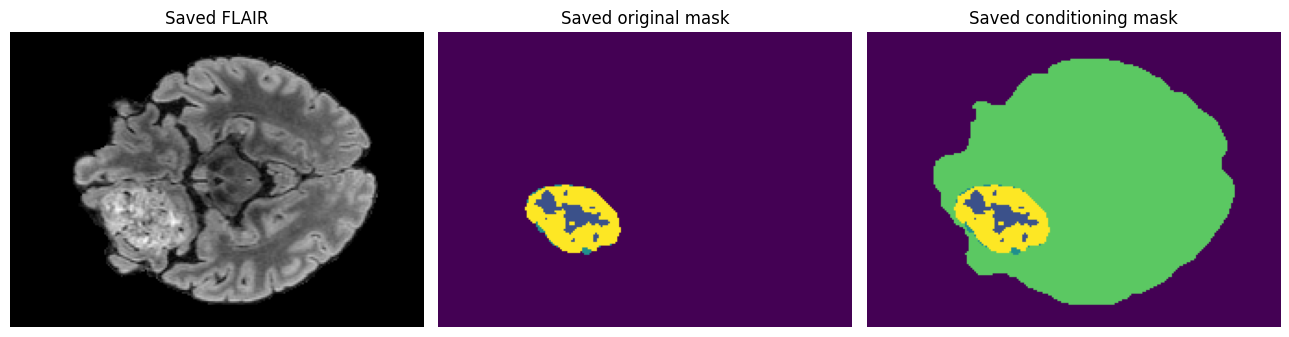

In [26]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
)

axes[0].imshow(
    saved_flair,
    cmap="gray",
)
axes[0].set_title("Saved FLAIR")
axes[0].axis("off")

axes[1].imshow(
    saved_original_mask,
    cmap="viridis",
    vmin=0,
    vmax=255,
)
axes[1].set_title("Saved original mask")
axes[1].axis("off")

axes[2].imshow(
    saved_condition_mask,
    cmap="viridis",
    vmin=0,
    vmax=255,
)
axes[2].set_title("Saved conditioning mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()